#Import Libraries

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
from scipy.ndimage import rotate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

# Giải nén
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Giải nén hoàn tất!")

Giải nén hoàn tất!


In [ ]:
# Xem danh sách thư mục con trong thư mục dataset
print(os.listdir(extract_path))

['test', 'train', 'data']


In [4]:
# Định nghĩa tham số
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 32
EPOCHS = 20
DATASET_PATH = '/content/dataset'

# Load Datasets

In [5]:
import os

def check_dataset_distribution(base_path):
    classes = ['benign', 'malignant']

    # Kiểm tra thư mục train
    train_path = os.path.join(base_path, 'train')
    print("\nThống kê dữ liệu trong thư mục train:")
    for cls in classes:
        cls_path = os.path.join(train_path, cls)
        num_images = len(os.listdir(cls_path))
        print(f"{cls}: {num_images} ảnh")

    # Kiểm tra thư mục test
    test_path = os.path.join(base_path, 'test')
    print("\nThống kê dữ liệu trong thư mục test:")
    for cls in classes:
        cls_path = os.path.join(test_path, cls)
        num_images = len(os.listdir(cls_path))
        print(f"{cls}: {num_images} ảnh")

    # Kiểm tra thư mục data/train và data/test
    data_path = os.path.join(base_path, 'data')
    for split in ['train', 'test']:
        split_path = os.path.join(data_path, split)
        print(f"\nThống kê dữ liệu trong thư mục data/{split}:")
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            try:
                num_images = len(os.listdir(cls_path))
                print(f"{cls}: {num_images} ảnh")
            except FileNotFoundError:
                print(f"{cls}: Thư mục không tồn tại")

# Gọi hàm kiểm tra
check_dataset_distribution(DATASET_PATH)


Thống kê dữ liệu trong thư mục train:
benign: 1440 ảnh
malignant: 1197 ảnh

Thống kê dữ liệu trong thư mục test:
benign: 360 ảnh
malignant: 300 ảnh

Thống kê dữ liệu trong thư mục data/train:
benign: 1440 ảnh
malignant: 1197 ảnh

Thống kê dữ liệu trong thư mục data/test:
benign: 360 ảnh
malignant: 300 ảnh


In [6]:
# Đường dẫn
train_path = os.path.join(DATASET_PATH, 'train')
test_path = os.path.join(DATASET_PATH, 'test')
classes = ['benign', 'malignant']

Hiển thị ảnh mẫu ngẫu nhiên từ thư mục train:


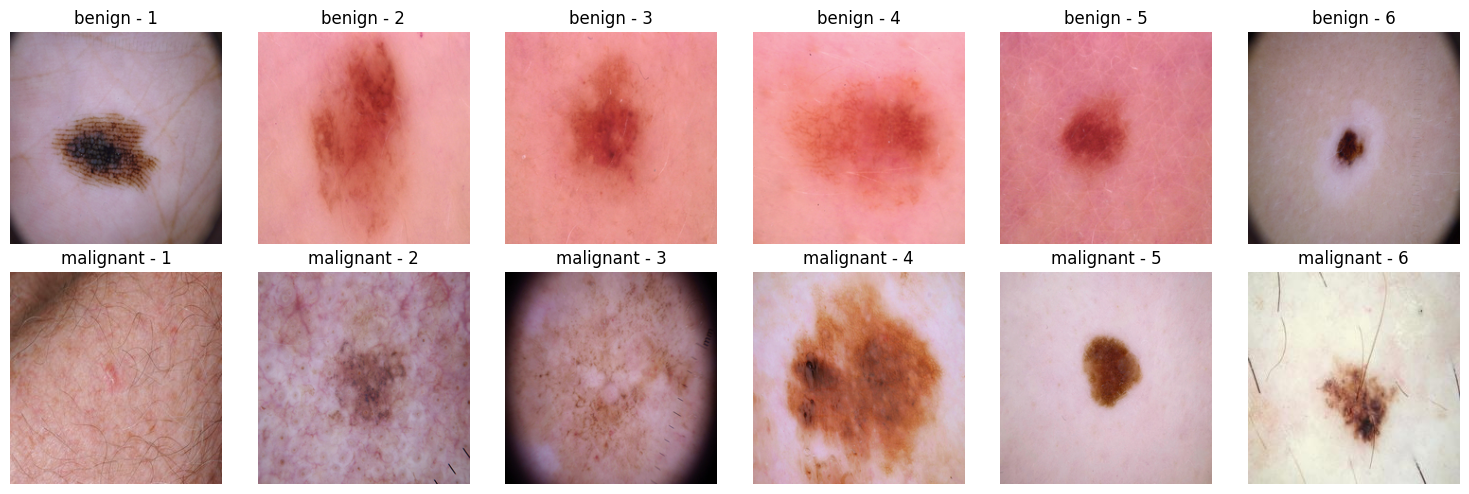

In [7]:
# Hàm hiển thị ảnh mẫu ngẫu nhiên
def display_sample_images(base_path, num_samples=3):
    plt.figure(figsize=(15, 5))

    for i, cls in enumerate(classes):
        cls_path = os.path.join(base_path, cls)
        img_files = os.listdir(cls_path)
        # Chọn ngẫu nhiên num_samples ảnh
        random_imgs = random.sample(img_files, min(num_samples, len(img_files)))

        for j, img_file in enumerate(random_imgs):
            img_path = os.path.join(cls_path, img_file)
            try:
                img = Image.open(img_path)
                img = img.resize((224, 224))  # Resize để hiển thị đồng nhất

                plt.subplot(2, num_samples, i * num_samples + j + 1)
                plt.imshow(img)
                plt.title(f"{cls} - {j+1}")
                plt.axis('off')
            except Exception as e:
                print(f"Lỗi khi mở ảnh {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Gọi hàm để hiển thị ảnh ngẫu nhiên từ thư mục train
print("Hiển thị ảnh mẫu ngẫu nhiên từ thư mục train:")
display_sample_images(train_path, num_samples=6)

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np
from scipy.ndimage import rotate
from tensorflow.keras.preprocessing.image import array_to_img


# Hàm áp dụng augmentation thủ công
def apply_manual_augmentation(img_array):
    # Xoay ngẫu nhiên 0-20 độ
    angle = np.random.uniform(-20, 20)
    rotated = rotate(img_array, angle, mode='nearest', reshape=False)

    # Lật ngang ngẫu nhiên
    if np.random.random() > 0.5:
        rotated = np.flip(rotated, axis=1)

    # Zoom nhẹ (crop và resize)
    zoom_factor = np.random.uniform(0.9, 1.1)
    new_height = int(IMG_HEIGHT * zoom_factor)
    new_width = int(IMG_WIDTH * zoom_factor)
    resized = np.array(Image.fromarray((rotated * 255).astype(np.uint8)).resize((new_width, new_height)))
    aug_img = np.array(Image.fromarray(resized).resize((IMG_HEIGHT, IMG_WIDTH))) / 255.0

    return aug_img

Hiển thị ảnh gốc và ảnh sau augmentation từ thư mục train:
Original benign image 1 - Min: 0.18039216101169586, Max: 0.9411764740943909
Augmented benign image 1 - Min: 0.19215686274509805, Max: 0.9411764705882353
Original benign image 2 - Min: 0.0941176488995552, Max: 0.9607843160629272
Augmented benign image 2 - Min: 0.10196078431372549, Max: 0.9529411764705882
Original benign image 3 - Min: 0.03921568766236305, Max: 0.7568627595901489
Augmented benign image 3 - Min: 0.047058823529411764, Max: 0.7529411764705882
Original malignant image 1 - Min: 0.07450980693101883, Max: 0.7843137383460999
Augmented malignant image 1 - Min: 0.08235294117647059, Max: 0.7764705882352941
Original malignant image 2 - Min: 0.0235294122248888, Max: 1.0
Augmented malignant image 2 - Min: 0.0392156862745098, Max: 0.9647058823529412
Original malignant image 3 - Min: 0.04313725605607033, Max: 0.7647058963775635
Augmented malignant image 3 - Min: 0.08235294117647059, Max: 0.7607843137254902


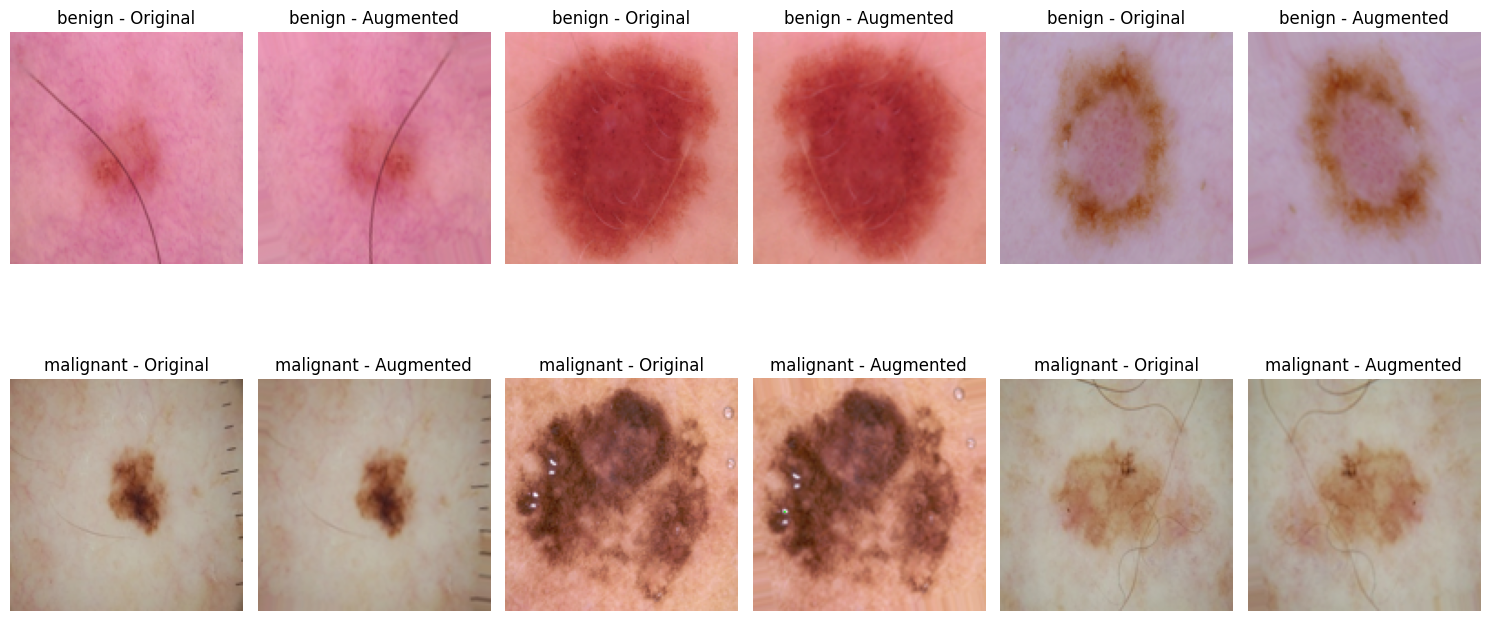

In [9]:
# Hàm hiển thị ảnh gốc và ảnh sau augmentation
def display_augmented_images(base_path, num_samples=3):
    classes = ['benign', 'malignant']
    plt.figure(figsize=(15, 8))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(base_path, cls)
        img_files = random.sample(os.listdir(cls_path), num_samples)
        for j, img_file in enumerate(img_files):
            img_path = os.path.join(cls_path, img_file)
            try:
                # Load ảnh gốc
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_HEIGHT, IMG_WIDTH))
                img_array = np.array(img, dtype=np.float32) / 255.0
                # Kiểm tra giá trị pixel của ảnh gốc
                print(f"Original {cls} image {j+1} - Min: {img_array.min()}, Max: {img_array.max()}")

                # Hiển thị ảnh gốc
                plt.subplot(len(classes), num_samples * 2, i * num_samples * 2 + j * 2 + 1)
                plt.imshow(img_array)
                plt.title(f"{cls} - Original")
                plt.axis('off')

                # Tạo và hiển thị ảnh augmented
                aug_img = apply_manual_augmentation(img_array)
                # Kiểm tra giá trị pixel của ảnh augmented
                print(f"Augmented {cls} image {j+1} - Min: {aug_img.min()}, Max: {aug_img.max()}")

                plt.subplot(len(classes), num_samples * 2, i * num_samples * 2 + j * 2 + 2)
                plt.imshow(aug_img)
                plt.title(f"{cls} - Augmented")
                plt.axis('off')
            except Exception as e:
                print(f"Lỗi khi mở ảnh {img_path}: {e}")
    plt.tight_layout()
    plt.show()

print("Hiển thị ảnh gốc và ảnh sau augmentation từ thư mục train:")
display_augmented_images(train_path, num_samples=3)

# Data Preprocessing

Found 2110 images belonging to 2 classes.
Hiển thị một số ảnh sau khi áp dụng augmentation từ train_datagen:


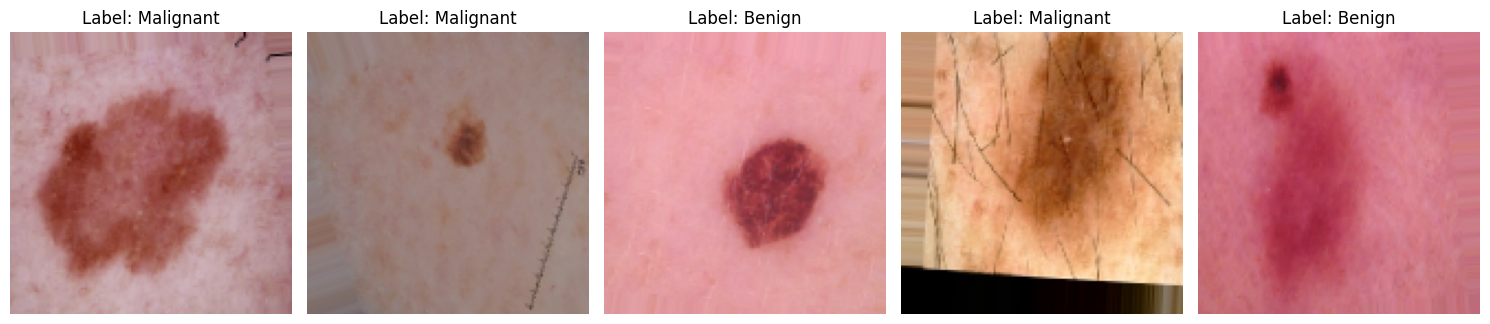

In [10]:
# Cấu hình lại train_datagen (giữ nguyên như trước)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Tạo train_generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    subset='training'
)

# Hàm hiển thị ảnh từ generator
def display_augmented_images_from_generator(generator, num_samples=5):
    # Lấy một batch ảnh từ generator
    images, labels = next(generator)
    indices = np.random.choice(len(images), num_samples, replace=False)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        img = images[idx]
        label = 'Malignant' if labels[idx] == 1 else 'Benign'
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Hiển thị một số ảnh sau khi áp dụng augmentation từ train_datagen:")
display_augmented_images_from_generator(train_generator, num_samples=5)

In [11]:
valid_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Tính class weights
labels = np.concatenate([np.zeros(1440), np.ones(1197)])
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Found 527 images belonging to 2 classes.
Found 660 images belonging to 2 classes.
Class weights: {0: np.float64(0.915625), 1: np.float64(1.1015037593984962)}


# CNN model

In [24]:
# Xây dựng và huấn luyện CNN
# Tinh chỉnh mô hình CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),  # Thêm layer để học đặc trưng phức tạp
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),                    # Tăng dropout để giảm overfitting
    Dense(1, activation='sigmoid')
])
# Hiển thị cấu trúc mô hình
print("Cấu trúc mô hình CNN:")
cnn_model.summary()

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Huấn luyện mô hình với validation
history_cnn = cnn_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=30,
    validation_data=valid_generator,  # Thêm validation
    validation_steps=valid_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping]
)

Cấu trúc mô hình CNN:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,177 (12.61 MB)

 Trainable params: 3,305,473 (12.61 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7437 - loss: 0.6125 - val_accuracy: 0.5625 - val_loss: 1.0034
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.8438 - loss: 0.3294 - val_accuracy: 0.5625 - val_loss: 1.0135
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8197 - loss: 0.4091 - val_accuracy: 0.5625 - val_loss: 1.2310
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.8125 - loss: 0.4182 - val_accuracy: 0.5625 - val_loss: 1.2302
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8244 - loss: 0.3872 - val_accuracy: 0.5625 - val_loss: 1.3109
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.8750 - loss: 0.2950 - val_accuracy: 0.5625 - val_loss: 1.3001
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8354 - loss: 0.3652 - val_accuracy: 0.5625 - val_loss: 0.8168
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.6875 - loss: 0.5472 - val_accuracy: 0.56

# Evaluation & Predict

Hiển thị ảnh sau dự đoán (CNN):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


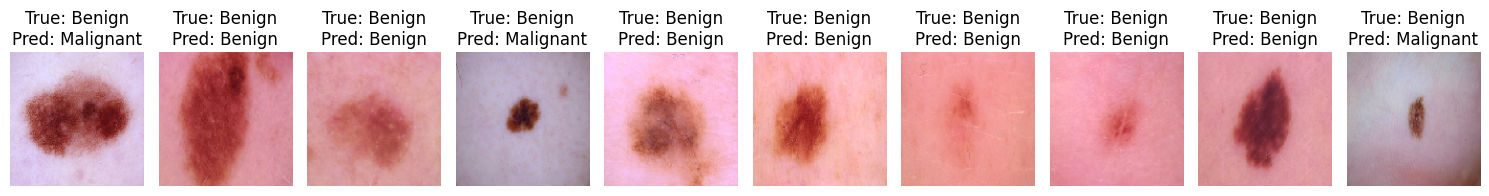

In [25]:
# Hiển thị ảnh dự đoán
def display_predicted_images(model, generator, num_samples=5):
    generator.reset()
    images, true_labels = next(generator)
    indices = np.random.choice(len(images), num_samples, replace=False)

    predictions = model.predict(images)
    pred_labels = (predictions > 0.5).astype(int)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        img = images[idx]
        true_label = 'Malignant' if true_labels[idx] == 1 else 'Benign'
        pred_label = 'Malignant' if pred_labels[idx] == 1 else 'Benign'
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Hiển thị ảnh sau dự đoán (CNN):")
display_predicted_images(cnn_model, test_generator, num_samples=10)


Đánh giá mô hình CNN:
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 323ms/step - accuracy: 0.7921 - loss: 0.3869
Test Accuracy: 0.8545, Test Loss: 0.3052
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 394ms/step


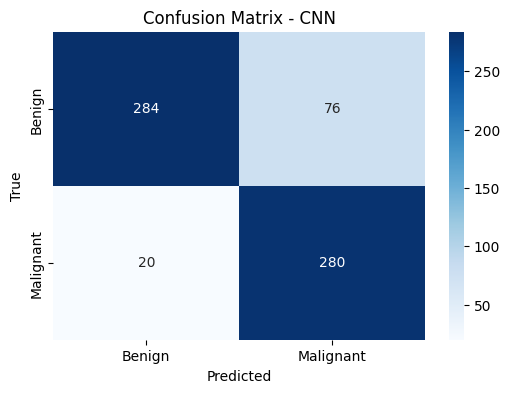

Classification Report - CNN:
              precision    recall  f1-score   support

      Benign       0.93      0.79      0.86       360
   Malignant       0.79      0.93      0.85       300

    accuracy                           0.85       660
   macro avg       0.86      0.86      0.85       660
weighted avg       0.87      0.85      0.85       660



In [26]:
# Đánh giá mô hình
print("\nĐánh giá mô hình CNN:")
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

y_pred = cnn_model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("Classification Report - CNN:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

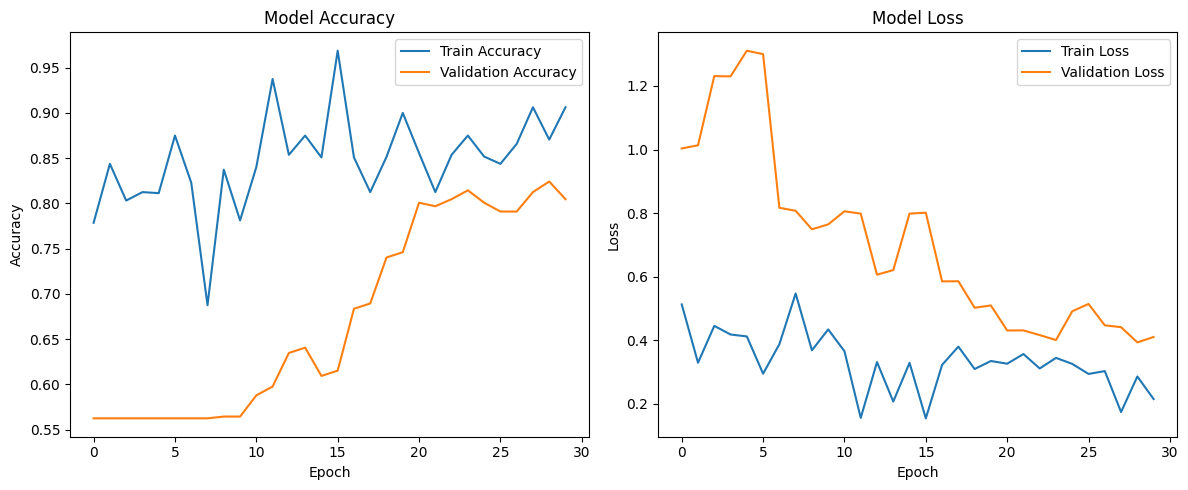

In [28]:
import matplotlib.pyplot as plt

# Tạo khung hình với kích thước 12x5
plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)  # 1 hàng, 2 cột, biểu đồ thứ 1
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Biểu đồ Loss
plt.subplot(1, 2, 2)  # 1 hàng, 2 cột, biểu đồ thứ 2
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Điều chỉnh layout để không bị chồng lấn
plt.tight_layout()
plt.show()